In [2]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)

theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

Warning message:
“package ‘DESeq2’ was built under R version 4.2.3”
Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.2.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.2.1”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    exp

In [5]:
de_df<- read.table(file = "../data/13_mature_rna_splicing_DE_results.tsv", sep = '\t', header = T, row.names = 1)

In [18]:
iso_level<- de_df$feature_id %>% sort() %>% unique()

mcolors <- c("#5E8C61FF",
             "#FFC857FF",
             "#D0AF84", 
             "#ADB9A1",
             "#8CBDBC",
             "#F0A96B",
             "#068D9D",
             "#B44E3FFF")

names(mcolors) = iso_level

mcolors_withsig = c(mcolors, "gray")
names(mcolors_withsig)<- c(names(mcolors), "Not sig")

mcol <- c("#80b1d3", "#fb8072", "grey")
names(mcol) <- c("Down in MUT", "Up in MUT", "Not sig")


de_df$type = as.character(de_df$feature_id)
de_df[de_df$labels == 'Not sig', 'type'] = 'Not sig'
de_df$type<- factor(de_df$type, levels = c(iso_level, 'Not sig'))
de_df[de_df$padj<10e-15, 'padj'] = 10e-15

Warning message:
“Removed 923 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“Removed 923 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


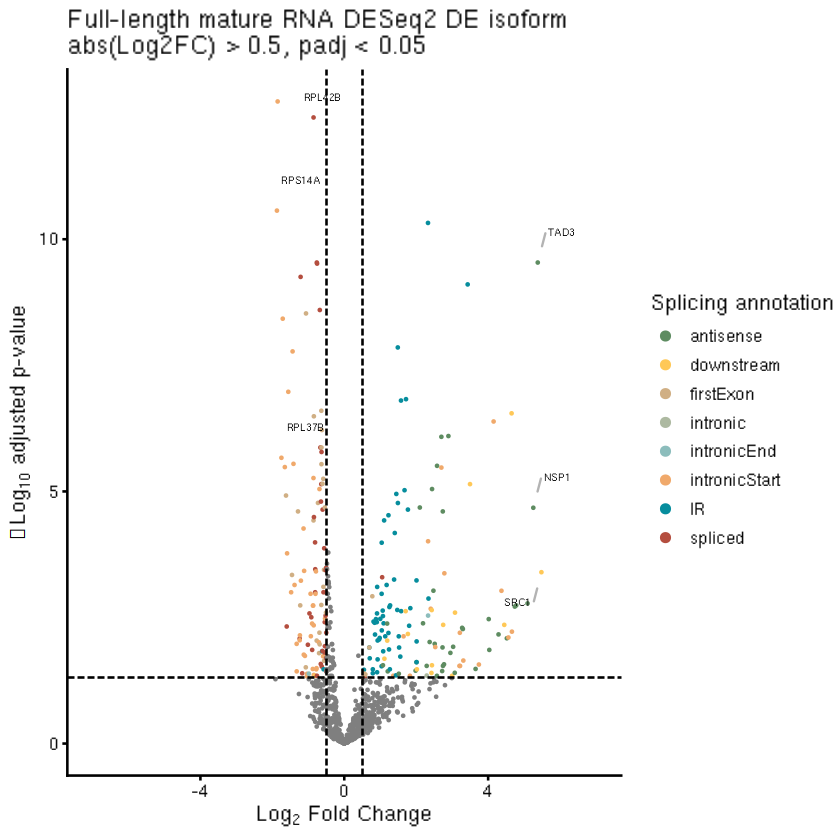

In [38]:
p <- de_df %>%
    ggplot(aes(x = log2FoldChange, y = -log10(padj), label = annotation)) +
    geom_point(aes(color = type), size = 0.2) +
    geom_text_repel(box.padding = 1, point.padding = 1, max.overlaps =10, size = 2, segment.color = "grey70") +
    labs(x = expression(Log[2] * " Fold Change"), y = expression(-Log[10] * " adjusted p-value"), 
       title = "Full-length mature RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05", color = "Splicing annotation")  +
    geom_hline(yintercept = -log10(0.05), color = 'black', linetype = "longdash") +
    geom_vline(xintercept = 0.5, color = 'black', linetype = "longdash") +
    geom_vline(xintercept = -0.5, color = 'black', linetype = "longdash") +
    scale_color_manual(values = mcolors) +
    guides(color = guide_legend(override.aes = list(size = 2))) +
    xlim(-7, 7)
p
ggsave('../figures/Figure4_mature_rna_isoform_DE_volcano.pdf', width = 5, height = 3)

In [41]:
de_df %>% filter(feature_id == "IR") %>% arrange(-log2FoldChange)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,lfcShrink,labels,gene_id,iso_id,feature_id,annotation,class,type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>
RIM1:IR_RIM1,33.519315,3.430840,0.5011719,6.845636,7.613669e-12,7.858999e-10,3.2899074,Up in MUT,RIM1,RIM1:IR,IR,NA,high,IR
NCE101:IR_NCE101,4.797517,2.498320,1.0317160,2.421519,1.545580e-02,5.091646e-02,1.4591130,Not sig,NCE101,NCE101:IR,IR,NA,medium,Not sig
AIM11:IR_AIM11,14.334924,2.341246,0.6161628,3.799720,1.448599e-04,1.332424e-03,2.0187021,Up in MUT,AIM11,AIM11:IR,IR,NA,medium,IR
RUB1:IR_RUB1,61.937751,2.327567,0.3168498,7.345964,2.042816e-13,4.744441e-11,2.2464473,Up in MUT,RUB1,RUB1:IR,IR,NA,medium,IR
DYN2:IR_DYN2,11.267323,2.011366,0.6432561,3.126851,1.766895e-03,9.433595e-03,1.5877823,Up in MUT,DYN2,DYN2:IR,IR,NA,high,IR
RPS17A:IR_RPS17A,8.629520,2.010619,0.7285871,2.759613,5.786985e-03,2.432629e-02,1.4424123,Up in MUT,RPS17A,RPS17A:IR,IR,NA,high,IR
SNC1:IR_SNC1,18.900749,2.008193,0.4952293,4.055077,5.011781e-05,5.819930e-04,1.7763721,Up in MUT,SNC1,SNC1:IR,IR,NA,medium,IR
DID4:IR_DID4,6.107600,1.954064,0.8571056,2.279841,2.261713e-02,6.691501e-02,1.0490614,Not sig,DID4,DID4:IR,IR,NA,medium,Not sig
RPS0A:IR_RPS0A,24.892614,1.837010,0.5014972,3.663051,2.492286e-04,2.067262e-03,1.5710847,Up in MUT,RPS0A,RPS0A:IR,IR,NA,high,IR


Joining with `by = join_by(labels)`


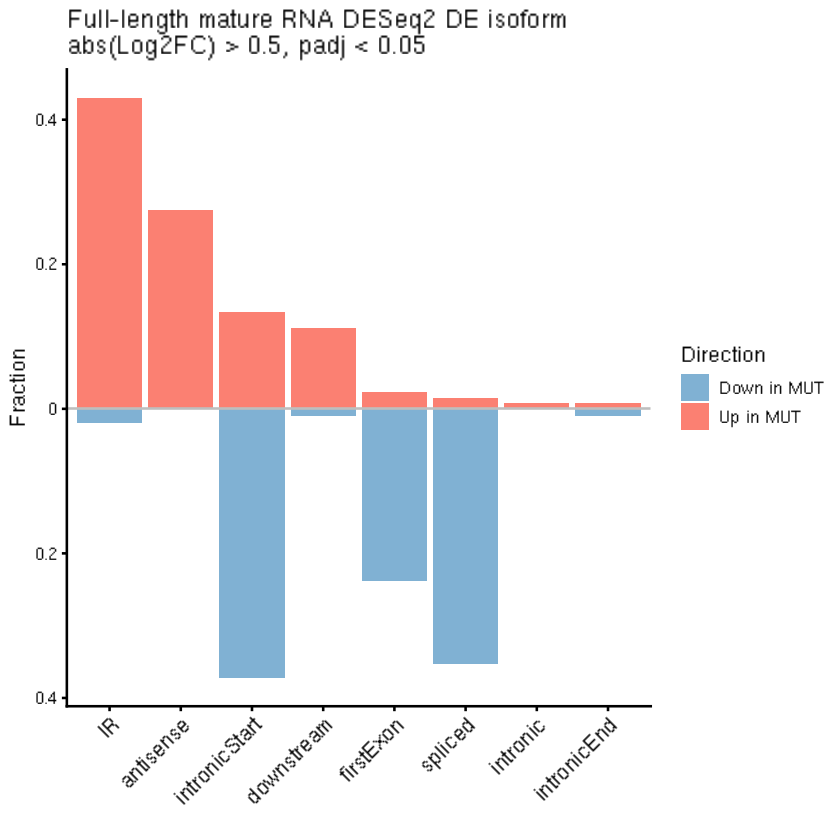

In [46]:
df<- de_df %>%
    count(labels, name = 'total_per_label') %>%
    left_join(count(de_df, labels, feature_id, name = 'feature_per_label')) %>% 
    mutate(frac = feature_per_label/total_per_label) %>% 
    mutate(frac = ifelse(labels == "Down in MUT", -frac, frac)) %>% 
    filter(labels != "Not sig")

order = df %>% arrange(-frac) %>% pull(feature_id) %>% unique()

df$feature_id<- factor(df$feature_id, levels = order)

ggplot(df, aes(x = feature_id, y = frac, fill = labels)) +
    geom_col() +
    scale_fill_manual(values = c("Down in MUT" = "#80b1d3", "Up in MUT" = "#fb8072")) +
    scale_y_continuous(labels = function(x) abs(x)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 12)) +
    geom_hline(yintercept = 0, color = "Gray") +
    labs(x = "", y = "Fraction", fill = "Direction",
         title ="Full-length mature RNA DESeq2 DE isoform\nabs(Log2FC) > 0.5, padj < 0.05")

ggsave('../figures/Figure4_mature_rna_isoform_DE_fraction.pdf', width = 5, height = 3.5)